In [1]:
import pandas as pd
data_eas_anreg = pd.read_excel("C:\\Users\\tisso\\OneDrive\\Dokumen\\Statistics Academic\\SEMESTER 3\\ANALISIS REGRESI\\FP\\DATA_EAS_ANREG.xlsx")

In [2]:
data_eas_anreg.head()

,Region,IKK,Jumlah Remaja,Sex Rasio,Dependensi Rasio,APK-PT,Status Wilayah,Jenis Wilayah
0,1,67.5,900,99.5,83.3,21.5,Kabupaten,Pesisir
1,2,78.0,822,105.3,87.5,22.0,Kabupaten,Region Antara Pesisir-Non Pesisir
2,3,80.8,781,102.3,78.4,19.6,Kabupaten,Non-Pesisir
3,4,67.0,805,98.9,89.9,22.5,Kabupaten,Pesisir
4,5,75.0,670,101.7,86.5,21.6,Kabupaten,Region Antara Pesisir-Non Pesisir


In [3]:
x5 = data_eas_anreg['Status Wilayah']
z1 = []
for i in range(len(x5)):
    if x5[i] == 'Kabupaten':
        z1.append(0)
    else:
        z1.append(1)

x6 = data_eas_anreg['Jenis Wilayah']
z2 = []
z3 = []

for i in range(len(x6)):
    if x6[i] == 'Pesisir':
        z2.append(0)
        z3.append(0)
    elif x6[i] == 'Region Antara Pesisir-Non Pesisir':
        z2.append(0)
        z3.append(1)
    else:
        z2.append(1)
        z3.append(0)

In [4]:
data_eas_anreg['Z1'] = z1
data_eas_anreg['Z2'] = z2
data_eas_anreg['Z3'] = z3
data_eas_anreg.head()

,Region,IKK,Jumlah Remaja,Sex Rasio,Dependensi Rasio,APK-PT,Status Wilayah,Jenis Wilayah,Z1,Z2,Z3
0,1,67.5,900,99.5,83.3,21.5,Kabupaten,Pesisir,0,0,0
1,2,78.0,822,105.3,87.5,22.0,Kabupaten,Region Antara Pesisir-Non Pesisir,0,0,1
2,3,80.8,781,102.3,78.4,19.6,Kabupaten,Non-Pesisir,0,1,0
3,4,67.0,805,98.9,89.9,22.5,Kabupaten,Pesisir,0,0,0
4,5,75.0,670,101.7,86.5,21.6,Kabupaten,Region Antara Pesisir-Non Pesisir,0,0,1


In [5]:
datafix = data_eas_anreg.drop(['Region','Status Wilayah','Jenis Wilayah'],axis=1)
datafix.head()

,IKK,Jumlah Remaja,Sex Rasio,Dependensi Rasio,APK-PT,Z1,Z2,Z3
0,67.5,900,99.5,83.3,21.5,0,0,0
1,78.0,822,105.3,87.5,22.0,0,0,1
2,80.8,781,102.3,78.4,19.6,0,1,0
3,67.0,805,98.9,89.9,22.5,0,0,0
4,75.0,670,101.7,86.5,21.6,0,0,1


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
matrix_corr = datafix.iloc[:,:-3].corr()
matrix_corr

,IKK,Jumlah Remaja,Sex Rasio,Dependensi Rasio,APK-PT
IKK,1.000000,0.285921,0.705839,-0.863538,-0.787514
Jumlah Remaja,0.285921,1.000000,0.297740,-0.203655,-0.203925
Sex Rasio,0.705839,0.297740,1.000000,-0.624149,-0.577563
Dependensi Rasio,-0.863538,-0.203655,-0.624149,1.000000,0.904940
APK-PT,-0.787514,-0.203925,-0.577563,0.904940,1.000000


<Axes: >

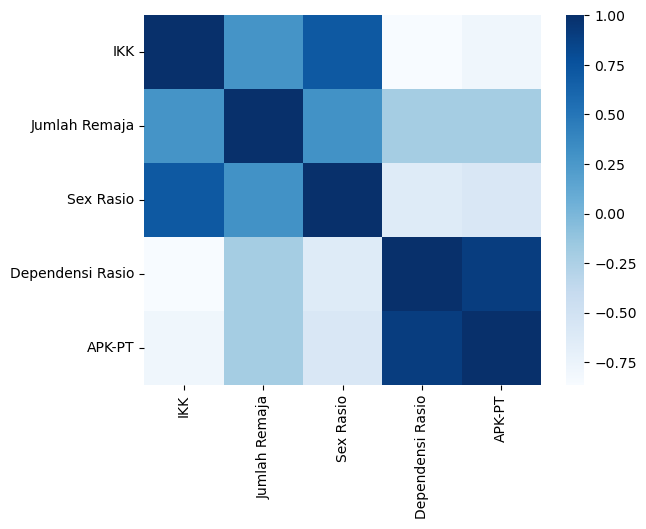

In [8]:
sns.heatmap(matrix_corr,cmap='Blues')

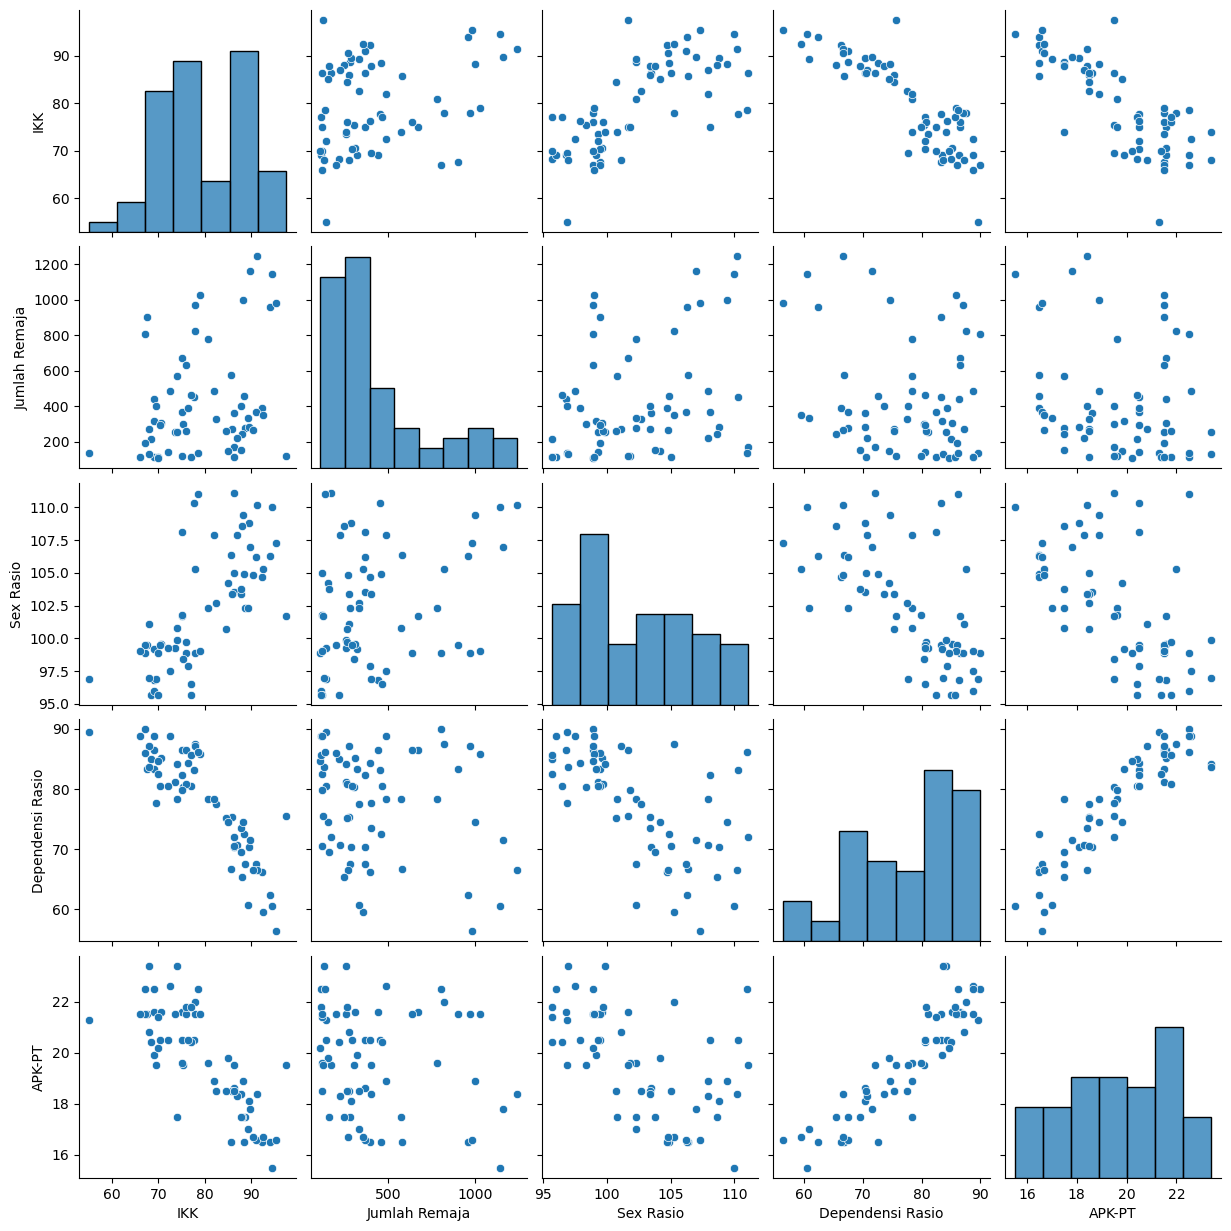

In [9]:
sns.pairplot(datafix.iloc[:,:-3])

In [10]:
y = datafix['IKK']
x = datafix.iloc[:,1:]

In [11]:
import statsmodels.api as sm

In [12]:
import numpy as np


In [13]:
xreg = sm.add_constant(x)
fullmodel1 = sm.OLS(y,xreg).fit()
fullmodel1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    IKK   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     55.38
Date:                Tue, 19 Dec 2023   Prob (F-statistic):           7.13e-23
Time:                        07:48:42   Log-Likelihood:                -167.55
No. Observations:                  64   AIC:                             351.1
Df Residuals:                      56   BIC:                             368.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               90.2293     17.228      5.237      0.000      55.717     124.742
Jumlah Remaja        0.0025      0.002      1.573      0.121      -0.001       0.006
Sex Rasio            0.2723      0.145      1.878      0.066      -0.018       0.563
Dependensi Rasio    -0.6085      0.132     -4.624      0.000      -0.872      -0.345
APK-PT               0.0729      0.537      0.136      0.893      -1.003       1.148
Z1                  -0.2774      1.148     -0.242      0.810      -2.578       2.023
Z2                   9.3089      1.710      5.445      0.000       5.884      12.733
Z3                   6.3170      1.290      4.896      0.000       3.732       8.902
==============================================================================
Omnibus:                       22.998   Durbin-Watson:                   1.992
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               76.579
Skew:                           0.889   Prob(JB):                     2.35e-17
Kurtosis:                       8.055   Cond. No.                     2.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Korelasi APK-PT dengan IKK bertanda negatif, sedangkan hasil koefisien regresi bertanda positif.

In [14]:
np.linalg.inv(xreg.T@xreg)@(xreg.T@y)

array([ 9.02293391e+01,  2.46519056e-03,  2.72299107e-01, -6.08476954e-01,
        7.28514350e-02, -2.77417151e-01,  9.30892869e+00,  6.31700223e+00])

In [15]:
def backward_elimination(X, y, significance_level=0.05):
    num_vars = len(X.columns)
    for i in range(0, num_vars):
        regressor_OLS = sm.OLS(y, X).fit()
        max_var = max(regressor_OLS.pvalues)
        if max_var > significance_level:
            for j in range(0, num_vars - i):
                if (regressor_OLS.pvalues.iloc[j] == max_var):
                    X = X.drop(X.columns[j], axis=1)
    return(X,regressor_OLS)
    
# Backward elimination
best_model = backward_elimination(xreg, y)
best_model[1].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    IKK   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     97.01
Date:                Tue, 19 Dec 2023   Prob (F-statistic):           3.02e-25
Time:                        07:48:42   Log-Likelihood:                -168.98
No. Observations:                  64   AIC:                             348.0
Df Residuals:                      59   BIC:                             358.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               86.6404     16.848      5.143      0.000      52.928     120.353
Sex Rasio            0.3261      0.138      2.363      0.021       0.050       0.602
Dependensi Rasio    -0.6019      0.077     -7.782      0.000      -0.757      -0.447
Z2                   8.9610      1.674      5.354      0.000       5.612      12.310
Z3                   6.4815      1.268      5.110      0.000       3.943       9.020
==============================================================================
Omnibus:                       16.171   Durbin-Watson:                   2.095
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               43.115
Skew:                           0.615   Prob(JB):                     4.34e-10
Kurtosis:                       6.828   Cond. No.                     4.91e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.91e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [16]:
yhat = best_model[1].predict(best_model[0])
residuals = y - yhat

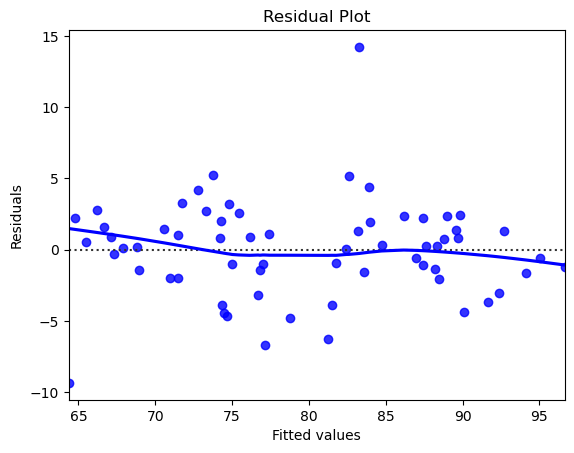

In [17]:
sns.residplot(x=yhat, y=residuals, lowess=True, color="b")
plt.title('Residual Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

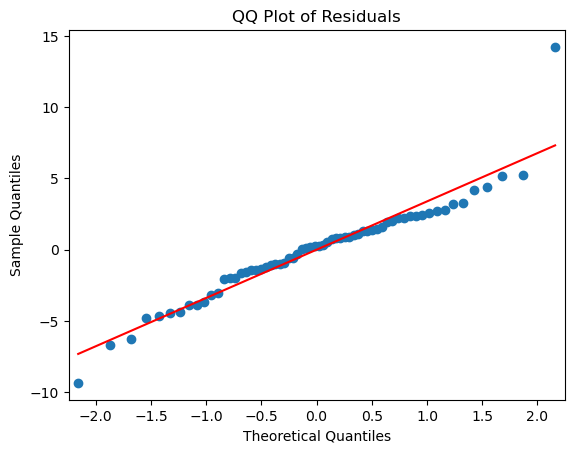

In [18]:
sm.qqplot(residuals, line='s')
plt.title("QQ Plot of Residuals")
plt.show()

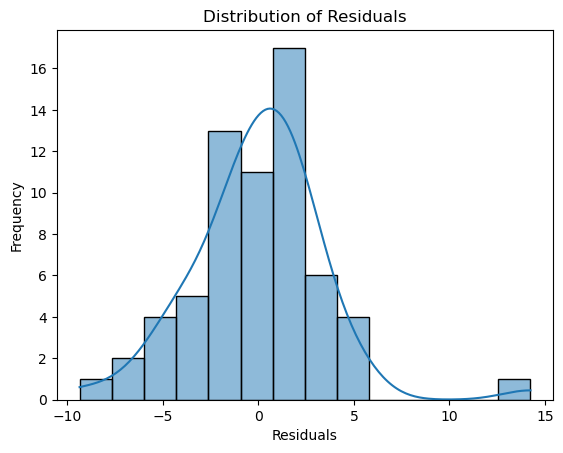

In [19]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [26]:
x2 = xreg.drop(['APK-PT'],axis=1)
model2 = 

,const,Jumlah Remaja,Sex Rasio,Dependensi Rasio,Z1,Z2,Z3
0,1.0,900,99.5,83.3,0,0,0
1,1.0,822,105.3,87.5,0,0,1
2,1.0,781,102.3,78.4,0,1,0
3,1.0,805,98.9,89.9,0,0,0
4,1.0,670,101.7,86.5,0,0,1
...,...,...,...,...,...,...,...
59,1.0,111,95.7,85.6,0,0,1
60,1.0,1163,107.0,71.5,1,1,0
61,1.0,116,99.0,88.8,0,0,0
62,1.0,122,101.7,75.6,1,1,0
